In [5]:
# Cell 1 — Load, restrict, and validate symbolic-analysis results.
from __future__ import annotations

import os
import re
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ntsa-symbolic")

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import font_manager
from scipy import stats


def locate_phase1(start: Path) -> Path:
    """Locate the phase1 directory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if candidate.name == "phase1" and (candidate / "results").is_dir():
            return candidate
        phase1 = candidate / "phase1"
        if (phase1 / "results").is_dir():
            return phase1
    raise FileNotFoundError("Could not locate phase1.")


PHASE1_DIR = locate_phase1(Path.cwd())
INPUT_DIR = PHASE1_DIR / "results" / "symbolic" / "processed"
OUTPUT_DIR = PHASE1_DIR / "outputs" / "symbolic"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WINDOW_SIZE_S = 60
WINDOW_TAG = f"{WINDOW_SIZE_S}s"
INTEGRITY_PATH = OUTPUT_DIR / f"symbolic_integrity_{WINDOW_TAG}.csv"
FILE_PATTERN = re.compile(r"session_(\d+)_symbolic_analysis\.csv")
STATES = ("Awake", "Drowsy")
METRIC_COLUMNS = ("pct_0v", "pct_1v", "pct_2v")
METRIC_LABELS = {
    "pct_0v": "0V",
    "pct_1v": "1V",
    "pct_2v": "2V",
}
EXPECTED_SESSIONS = 20
COMPOSITION_TOLERANCE = 1e-8
integrity_rows: list[dict[str, object]] = []


def require(name: str, condition: bool, details: str) -> None:
    """Record an integrity check and fail loudly when needed."""
    integrity_rows.append(
        {"check": name, "passed": bool(condition), "details": details}
    )
    if not condition:
        pd.DataFrame(integrity_rows).to_csv(INTEGRITY_PATH, index=False)
        raise AssertionError(f"{name}: {details}")


file_map: dict[int, Path] = {}
for path in sorted(INPUT_DIR.glob("session_*_symbolic_analysis.csv")):
    match = FILE_PATTERN.fullmatch(path.name)
    require("recognized_filename", match is not None, path.name)
    session_id = int(match.group(1))
    require(
        f"unique_file_session_{session_id:02d}",
        session_id not in file_map,
        path.name,
    )
    file_map[session_id] = path
require(
    "exactly_20_symbolic_files",
    len(file_map) == EXPECTED_SESSIONS,
    f"found={len(file_map)}",
)
sessions = sorted(file_map)
required_columns = {
    "session_id",
    "representation",
    "window_uid",
    "window_size_s",
    "window_id",
    "state",
    "pct_0v",
    "pct_1v",
    "pct_2lv",
    "pct_2uv",
    "pct_2v",
    "symbolic_invariants_pass",
    "symbolic_valid",
    "analysis_included",
}
frames = []
for session_id in sessions:
    path = file_map[session_id]
    frame = pd.read_csv(path)
    missing = sorted(required_columns.difference(frame.columns))
    require(
        f"schema_session_{session_id:02d}",
        not missing,
        f"missing={missing}",
    )
    require(
        f"filename_session_match_{session_id:02d}",
        set(frame["session_id"].astype(int)) == {session_id},
        path.name,
    )
    frames.append(frame)
symbolic_all = pd.concat(frames, ignore_index=True)
primary_all = symbolic_all.loc[
    symbolic_all["representation"].str.casefold().eq("processed")
    & symbolic_all["window_size_s"].eq(WINDOW_SIZE_S)
    & symbolic_all["state"].isin(STATES)
].copy()
included_mask = primary_all["analysis_included"].astype(bool)
symbolic_data = primary_all.loc[included_mask].copy()
require(
    "all_20_sessions_in_primary_cohort",
    set(symbolic_data["session_id"].astype(int)) == set(sessions),
    f"found={symbolic_data['session_id'].nunique()}",
)
for state in STATES:
    state_sessions = symbolic_data.loc[
        symbolic_data["state"].eq(state), "session_id"
    ].nunique()
    require(
        f"both_states_{state.lower()}",
        state_sessions == EXPECTED_SESSIONS,
        f"sessions={state_sessions}",
    )
require(
    "unique_window_uid",
    not primary_all["window_uid"].duplicated().any(),
    f"duplicates={primary_all['window_uid'].duplicated().sum()}",
)
metric_values = symbolic_data[list(METRIC_COLUMNS)].to_numpy(dtype=float)
require(
    "finite_primary_symbolic_metrics",
    np.isfinite(metric_values).all(),
    f"nonfinite={int((~np.isfinite(metric_values)).sum())}",
)
require(
    "included_rows_are_symbolic_valid",
    symbolic_data["symbolic_valid"].astype(bool).all(),
    "all included rows",
)
require(
    "included_rows_pass_invariants",
    symbolic_data["symbolic_invariants_pass"].astype(bool).all(),
    "all included rows",
)
composition = symbolic_data[list(METRIC_COLUMNS)].sum(axis=1)
composition_error = np.abs(composition - 100.0)
require(
    "0V_1V_2V_sum_to_100_percent",
    composition_error.le(COMPOSITION_TOLERANCE).all(),
    f"max_abs_error={composition_error.max():.3g}",
)
split_error = np.abs(
    symbolic_data["pct_2lv"]
    + symbolic_data["pct_2uv"]
    - symbolic_data["pct_2v"]
)
require(
    "2V_equals_2LV_plus_2UV",
    split_error.le(COMPOSITION_TOLERANCE).all(),
    f"max_abs_error={split_error.max():.3g}",
)
window_counts = (
    symbolic_data.groupby(["session_id", "state"], sort=True)
    .size()
    .rename("n_windows")
    .reset_index()
)
integrity_report = pd.DataFrame(integrity_rows)
integrity_report.to_csv(INTEGRITY_PATH, index=False)
print(
    f"Symbolic integrity PASSED | files={len(file_map)} | "
    f"all rows={len(symbolic_all)} | primary {WINDOW_SIZE_S}-s="
    f"{len(primary_all)} | "
    f"included={len(symbolic_data)} | excluded={len(primary_all) - len(symbolic_data)}"
)
print(symbolic_data["state"].value_counts().reindex(STATES).to_string())
display(window_counts)
display(integrity_report.tail(10))


Symbolic integrity PASSED | files=20 | all rows=1544 | primary 60-s=901 | included=901 | excluded=0
state
Awake     596
Drowsy    305


,session_id,state,n_windows
0,1,Awake,24
1,1,Drowsy,7
2,4,Awake,29
3,4,Drowsy,17
4,5,Awake,33
5,5,Drowsy,16
6,6,Awake,31
7,6,Drowsy,17
8,7,Awake,34
9,7,Drowsy,11


,check,passed,details
80,filename_session_match_25,True,session_25_symbolic_analysis.csv
81,all_20_sessions_in_primary_cohort,True,found=20
82,both_states_awake,True,sessions=20
83,both_states_drowsy,True,sessions=20
84,unique_window_uid,True,duplicates=0
85,finite_primary_symbolic_metrics,True,nonfinite=0
86,included_rows_are_symbolic_valid,True,all included rows
87,included_rows_pass_invariants,True,all included rows
88,0V_1V_2V_sum_to_100_percent,True,max_abs_error=2.84e-14
89,2V_equals_2LV_plus_2UV,True,max_abs_error=1.42e-14


In [6]:
# Cell 2 — Session-level paired symbolic effects and formal inference.
BOOTSTRAP_RESAMPLES = 20_000
BOOTSTRAP_SEED = 20260902


def bootstrap_median_ci(
    values: np.ndarray, seed: int
) -> tuple[float, float]:
    """Return a percentile bootstrap CI for the paired median."""
    rng = np.random.default_rng(seed)
    indices = rng.integers(
        0, len(values), size=(BOOTSTRAP_RESAMPLES, len(values))
    )
    medians = np.median(values[indices], axis=1)
    low, high = np.percentile(medians, [2.5, 97.5])
    return float(low), float(high)


def paired_rank_biserial(values: np.ndarray) -> float:
    """Return matched-pairs signed-rank rank-biserial effect size."""
    nonzero = values[values != 0.0]
    if nonzero.size == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(nonzero), method="average")
    positive = ranks[nonzero > 0.0].sum()
    negative = ranks[nonzero < 0.0].sum()
    return float((positive - negative) / (positive + negative))


def benjamini_hochberg(p_values: np.ndarray) -> np.ndarray:
    """Adjust one family of p-values with BH-FDR."""
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values, kind="stable")
    ordered = p_values[order]
    adjusted = ordered * len(ordered) / np.arange(1, len(ordered) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    result = np.empty_like(adjusted)
    result[order] = np.clip(adjusted, 0.0, 1.0)
    return result


session_state_summary = (
    symbolic_data.groupby(["session_id", "state"], sort=True)[
        list(METRIC_COLUMNS)
    ]
    .median()
    .reset_index()
)
if len(session_state_summary) != EXPECTED_SESSIONS * len(STATES):
    raise AssertionError("Expected one row per session and state.")
session_state_path = (
    OUTPUT_DIR / f"symbolic_session_state_{WINDOW_TAG}.csv"
)
session_state_summary.to_csv(session_state_path, index=False)

comparison_rows = []
paired_value_frames = []
for metric_index, metric in enumerate(METRIC_COLUMNS):
    paired = session_state_summary.pivot(
        index="session_id", columns="state", values=metric
    ).reindex(index=sessions, columns=STATES)
    if paired.isna().any().any() or len(paired) != EXPECTED_SESSIONS:
        raise AssertionError(f"Incomplete pairing for {metric}.")
    delta = (paired["Drowsy"] - paired["Awake"]).to_numpy(dtype=float)
    ci_low, ci_high = bootstrap_median_ci(
        delta, BOOTSTRAP_SEED + metric_index
    )
    if np.all(delta == 0.0):
        statistic, p_value = 0.0, 1.0
    else:
        test = stats.wilcoxon(
            delta,
            zero_method="wilcox",
            correction=False,
            alternative="two-sided",
            method="auto",
        )
        statistic, p_value = float(test.statistic), float(test.pvalue)
    comparison_rows.append(
        {
            "metric": METRIC_LABELS[metric],
            "source_column": metric,
            "n_paired_sessions": len(delta),
            "awake_median": float(paired["Awake"].median()),
            "drowsy_median": float(paired["Drowsy"].median()),
            "median_delta_drowsy_minus_awake": float(np.median(delta)),
            "ci95_low": ci_low,
            "ci95_high": ci_high,
            "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
            "bootstrap_seed": BOOTSTRAP_SEED + metric_index,
            "wilcoxon_statistic": statistic,
            "raw_p_value": p_value,
            "rank_biserial_r_rb": paired_rank_biserial(delta),
            "n_positive": int(np.count_nonzero(delta > 0.0)),
            "n_negative": int(np.count_nonzero(delta < 0.0)),
            "n_zero": int(np.count_nonzero(delta == 0.0)),
        }
    )
    paired_frame = paired.reset_index()
    paired_frame["metric"] = METRIC_LABELS[metric]
    paired_frame["delta_drowsy_minus_awake"] = delta
    paired_value_frames.append(paired_frame)
symbolic_comparison = pd.DataFrame(comparison_rows)
if len(symbolic_comparison) != 3:
    raise AssertionError("The symbolic BH-FDR family must contain 3 tests.")
symbolic_comparison["q_BH"] = benjamini_hochberg(
    symbolic_comparison["raw_p_value"].to_numpy()
)
symbolic_comparison["BH_supported"] = symbolic_comparison["q_BH"].le(
    0.05
)
symbolic_comparison["CI_excludes_zero"] = (
    symbolic_comparison["ci95_low"].gt(0.0)
    | symbolic_comparison["ci95_high"].lt(0.0)
)
comparison_path = (
    OUTPUT_DIR / f"symbolic_state_comparison_{WINDOW_TAG}.csv"
)
symbolic_comparison.to_csv(comparison_path, index=False)
paired_values = pd.concat(paired_value_frames, ignore_index=True)
paired_values_path = (
    OUTPUT_DIR / f"symbolic_paired_values_{WINDOW_TAG}.csv"
)
paired_values.to_csv(paired_values_path, index=False)
print(
    "Formal choice: one BH-FDR family across 0V, 1V, and 2V. "
    "Interpretation remains focused on 0V and 2V."
)
print(
    f"Saved {comparison_path.name}, {session_state_path.name}, and "
    f"{paired_values_path.name}."
)
display(symbolic_comparison)


Formal choice: one BH-FDR family across 0V, 1V, and 2V. Interpretation remains focused on 0V and 2V.
Saved symbolic_state_comparison_60s.csv, symbolic_session_state_60s.csv, and symbolic_paired_values_60s.csv.


,metric,source_column,n_paired_sessions,awake_median,drowsy_median,median_delta_drowsy_minus_awake,ci95_low,ci95_high,bootstrap_resamples,bootstrap_seed,wilcoxon_statistic,raw_p_value,rank_biserial_r_rb,n_positive,n_negative,n_zero,q_BH,BH_supported,CI_excludes_zero
0,0V,pct_0v,20,22.887026,24.688032,4.043522,0.352402,7.184325,20000,20260902,53.0,0.053169,0.495238,14,6,0,0.113777,False,True
1,1V,pct_1v,20,42.471253,43.406224,0.408287,-1.468323,2.226891,20000,20260903,86.0,0.498009,0.180952,10,10,0,0.498009,False,False
2,2V,pct_2v,20,33.154534,30.597879,-0.905473,-6.403204,0.371321,20000,20260904,57.0,0.075851,-0.457143,7,13,0,0.113777,False,False


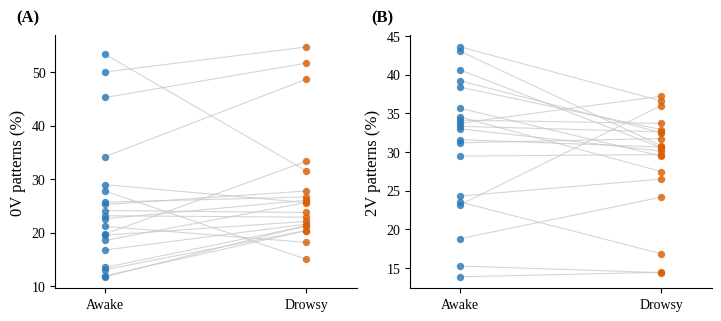

Saved symbolic_0V_2V_state_60s.pdf, symbolic_0V_2V_state_60s.svg, and symbolic_0V_2V_state_60s.png using Liberation Serif.


In [7]:
# Cell 3 — Publication figure for 0V and 2V paired state effects.
def select_serif_font() -> str:
    """Select Times New Roman or the approved serif fallback."""
    available = {font.name for font in font_manager.fontManager.ttflist}
    for family in ("Times New Roman", "Liberation Serif", "DejaVu Serif"):
        if family in available:
            return family
    return "serif"


PLOT_FONT = select_serif_font()
mpl.rcParams.update(
    {
        "font.family": PLOT_FONT,
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
)
STATE_COLORS = {"Awake": "#2878B5", "Drowsy": "#D95F02"}
figure_metrics = (
    ("pct_0v", "0V patterns (%)", "(A)"),
    ("pct_2v", "2V patterns (%)", "(B)"),
)
fig, axes = plt.subplots(
    1, 2, figsize=(7.10, 3.10), constrained_layout=True
)
for axis, (metric, ylabel, panel) in zip(axes, figure_metrics):
    paired = session_state_summary.pivot(
        index="session_id", columns="state", values=metric
    ).reindex(index=sessions, columns=STATES)
    for session_id, row in paired.iterrows():
        axis.plot(
            [0, 1],
            [row["Awake"], row["Drowsy"]],
            color="0.78",
            linewidth=0.8,
            alpha=0.75,
            zorder=1,
        )
    axis.scatter(
        np.zeros(len(paired)),
        paired["Awake"],
        s=28,
        color=STATE_COLORS["Awake"],
        alpha=0.82,
        linewidths=0.0,
        zorder=2,
    )
    axis.scatter(
        np.ones(len(paired)),
        paired["Drowsy"],
        s=28,
        color=STATE_COLORS["Drowsy"],
        alpha=0.82,
        linewidths=0.0,
        zorder=2,
    )
    axis.set_xticks([0, 1], STATES)
    axis.set_xlim(-0.25, 1.25)
    axis.set_ylabel(ylabel)
    axis.text(
        -0.13,
        1.04,
        panel,
        transform=axis.transAxes,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="bottom",
    )
figure_pdf = OUTPUT_DIR / f"symbolic_0V_2V_state_{WINDOW_TAG}.pdf"
figure_svg = OUTPUT_DIR / f"symbolic_0V_2V_state_{WINDOW_TAG}.svg"
figure_png = OUTPUT_DIR / f"symbolic_0V_2V_state_{WINDOW_TAG}.png"
fig.savefig(figure_pdf, bbox_inches="tight")
fig.savefig(figure_svg, bbox_inches="tight")
fig.savefig(figure_png, dpi=600, bbox_inches="tight")
plt.show()
print(
    f"Saved {figure_pdf.name}, {figure_svg.name}, and {figure_png.name} "
    f"using {PLOT_FONT}."
)


In [8]:
# Cell 4 — Session table, compact evidence, and manuscript-ready conclusion.
session_symbolic_table = (
    session_state_summary.loc[
        :, ["session_id", "state", "pct_0v", "pct_2v"]
    ]
    .assign(
        _state_order=lambda frame: frame["state"].map(
            {"Awake": 0, "Drowsy": 1}
        )
    )
    .sort_values(["session_id", "_state_order"])
    .drop(columns="_state_order")
    .rename(
        columns={
            "session_id": "Session",
            "state": "State",
            "pct_0v": "Median 0V (%)",
            "pct_2v": "Median 2V (%)",
        }
    )
    .reset_index(drop=True)
)
if len(session_symbolic_table) != EXPECTED_SESSIONS * len(STATES):
    raise AssertionError("Expected exactly 40 session-state rows.")
print("Session-level relationship between 0V and 2V (40 rows):")
with pd.option_context("display.max_rows", 40):
    display(
        session_symbolic_table.style.format(
            {"Median 0V (%)": "{:.3f}", "Median 2V (%)": "{:.3f}"}
        ).hide(axis="index")
    )

def classify_symbolic_evidence(row: pd.Series) -> str:
    """Classify multiplicity-controlled symbolic evidence."""
    if row["BH_supported"]:
        return "BH-FDR supported"
    directional_majority = max(row["n_positive"], row["n_negative"]) > 10
    if row["CI_excludes_zero"] and directional_majority:
        return "Directionally consistent but weaker"
    return "No clear state effect"


final_symbolic = symbolic_comparison.copy()
final_symbolic["direction"] = np.where(
    final_symbolic["median_delta_drowsy_minus_awake"].gt(0.0),
    "Higher in Drowsy",
    np.where(
        final_symbolic["median_delta_drowsy_minus_awake"].lt(0.0),
        "Lower in Drowsy",
        "No median change",
    ),
)
final_symbolic["evidence_class"] = final_symbolic.apply(
    classify_symbolic_evidence, axis=1
)
final_symbolic["ci95"] = final_symbolic.apply(
    lambda row: f"[{row['ci95_low']:.3f}, {row['ci95_high']:.3f}]",
    axis=1,
)
final_table = final_symbolic[
    [
        "metric",
        "awake_median",
        "drowsy_median",
        "median_delta_drowsy_minus_awake",
        "ci95",
        "rank_biserial_r_rb",
        "q_BH",
        "direction",
        "evidence_class",
    ]
].rename(
    columns={
        "metric": "Metric",
        "awake_median": "Awake",
        "drowsy_median": "Drowsy",
        "median_delta_drowsy_minus_awake": "Median Delta",
        "ci95": "95% CI",
        "rank_biserial_r_rb": "r_rb",
        "q_BH": "q_BH",
        "direction": "Direction",
        "evidence_class": "Evidence class",
    }
)
final_table_path = (
    OUTPUT_DIR / f"symbolic_final_evidence_{WINDOW_TAG}.csv"
)
final_table.to_csv(final_table_path, index=False)


def metric_finding(metric: str) -> str:
    """Create one manuscript-ready symbolic metric sentence."""
    row = final_symbolic.loc[final_symbolic["metric"].eq(metric)].iloc[0]
    change = "increased" if row["median_delta_drowsy_minus_awake"] > 0 else "decreased"
    return (
        f"- {metric} {change} in Drowsy: median Delta="
        f"{row['median_delta_drowsy_minus_awake']:.3f} percentage points, "
        f"95% CI [{row['ci95_low']:.3f}, {row['ci95_high']:.3f}], "
        f"r_rb={row['rank_biserial_r_rb']:.3f}, q_BH={row['q_BH']:.4f}; "
        f"{row['evidence_class']}."
    )


primary_rows = final_symbolic.loc[final_symbolic["metric"].isin(["0V", "2V"])]
supported_primary = primary_rows.loc[primary_rows["BH_supported"], "metric"].tolist()
if supported_primary:
    opening = (
        "Drowsiness was associated with BH-FDR-supported changes in "
        + " and ".join(supported_primary)
        + " symbolic pattern composition."
    )
else:
    opening = (
        "Drowsiness showed directional changes in 0V and 2V symbolic "
        "pattern composition, without BH-FDR support."
    )
conclusion = "\n".join(
    [
        "## Symbolic analysis — Final finding",
        "",
        opening,
        "",
        metric_finding("0V"),
        metric_finding("2V"),
        "",
        "Paired session-level effects used median Drowsy-minus-Awake "
        "differences, 20,000-resample bootstrap confidence intervals, "
        "Wilcoxon signed-rank tests, rank-biserial effect sizes, and one "
        "BH-FDR correction family across 0V, 1V, and 2V.",
        "",
        "The shift in symbolic pattern composition provides complementary "
        "physiological context for the dynamical reorganization identified "
        "by Prediction, RQA, and LLE.",
        "",
        "These findings are consistent with altered autonomic modulation "
        "during drowsiness and compatible with a shift in autonomic balance. "
        "They are not direct evidence of a specific causal sympathetic or "
        "parasympathetic mechanism.",
    ]
)
conclusion_path = OUTPUT_DIR / f"symbolic_conclusion_{WINDOW_TAG}.md"
conclusion_path.write_text(conclusion + "\n", encoding="utf-8")
print(f"Saved {final_table_path.name} and {conclusion_path.name}.")
display(final_table)
display(Markdown(conclusion))


Session-level relationship between 0V and 2V (40 rows):


Session,State,Median 0V (%),Median 2V (%)
1,Awake,18.563,35.632
1,Drowsy,25.641,29.487
4,Awake,28.947,24.324
4,Drowsy,25.610,26.506
5,Awake,45.238,15.278
5,Drowsy,51.652,14.420
6,Awake,11.765,40.580
6,Drowsy,21.333,30.556
7,Awake,16.775,38.367
7,Drowsy,21.591,32.895


Saved symbolic_final_evidence_60s.csv and symbolic_conclusion_60s.md.


,Metric,Awake,Drowsy,Median Delta,95% CI,r_rb,q_BH,Direction,Evidence class
0,0V,22.887026,24.688032,4.043522,"[0.352, 7.184]",0.495238,0.113777,Higher in Drowsy,Directionally consistent but weaker
1,1V,42.471253,43.406224,0.408287,"[-1.468, 2.227]",0.180952,0.498009,Higher in Drowsy,No clear state effect
2,2V,33.154534,30.597879,-0.905473,"[-6.403, 0.371]",-0.457143,0.113777,Lower in Drowsy,No clear state effect


## Symbolic analysis — Final finding

Drowsiness showed directional changes in 0V and 2V symbolic pattern composition, without BH-FDR support.

- 0V increased in Drowsy: median Delta=4.044 percentage points, 95% CI [0.352, 7.184], r_rb=0.495, q_BH=0.1138; Directionally consistent but weaker.
- 2V decreased in Drowsy: median Delta=-0.905 percentage points, 95% CI [-6.403, 0.371], r_rb=-0.457, q_BH=0.1138; No clear state effect.

Paired session-level effects used median Drowsy-minus-Awake differences, 20,000-resample bootstrap confidence intervals, Wilcoxon signed-rank tests, rank-biserial effect sizes, and one BH-FDR correction family across 0V, 1V, and 2V.

The shift in symbolic pattern composition provides complementary physiological context for the dynamical reorganization identified by Prediction, RQA, and LLE.

These findings are consistent with altered autonomic modulation during drowsiness and compatible with a shift in autonomic balance. They are not direct evidence of a specific causal sympathetic or parasympathetic mechanism.

### Symbolic dynamics — Final decision

Phân tích symbolic được giữ ở **60-s Processed PPG** để duy trì tính nhất quán với primary analysis của nghiên cứu.

Thử nghiệm 120 s không làm các hiệu ứng ổn định hơn và cho variability lớn hơn giữa các phiên, do đó không được sử dụng để thay thế kết quả chính.

Ở 60 s, symbolic metrics cho một xu hướng sinh lý có định hướng:

- `0V` tăng trong Drowsy.
- `2V` giảm trong Drowsy.
- `1V` thay đổi rất ít.

Tuy nhiên, các effect này chưa được hỗ trợ sau BH-FDR và vì vậy chỉ được diễn giải như **bằng chứng sinh lý bổ trợ**, không phải một primary finding độc lập.

Symbolic analysis được dùng để cung cấp ngữ cảnh cho khả năng **autonomic modulation thay đổi trong drowsiness**, trong khi các kết luận chính về dynamical reorganization vẫn dựa trên Prediction, RQA và LLE.